# IMPORT LIBRARIES & LOAD DATASET

In [2]:
import pandas as pd
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_finalfinal.csv'
)

In [6]:
womens_world_cup_stats

,match_id,team,match_date,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,dribbles,successful_dribbles,dribble_success_pct,duels,duels_won,counterpress_actions,goals_from_shots,own_goals_for,own_goals_against,goal_type
0,3893787,New Zealand Women's,2023-07-20,Norway Women's,Group,1,0,W,3,57.781529,...,13,6,46.15,59,13,65,1,0,0,Goal
1,3893787,Norway Women's,2023-07-20,New Zealand Women's,Group,0,1,L,0,42.218471,...,21,8,38.10,47,12,55,0,0,0,Goal
2,3893788,Australia Women's,2023-07-20,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,21,12,57.14,34,12,47,1,0,0,Goal
3,3893788,Republic of Ireland Women's,2023-07-20,Australia Women's,Group,0,1,L,0,41.986622,...,10,3,30.00,48,15,73,0,0,0,Goal
4,3893789,Philippines Women's,2023-07-21,Switzerland Women's,Group,0,2,L,0,30.212373,...,11,7,63.64,29,5,74,0,0,0,Goal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,3904629,England Women's,2023-08-16,Australia Women's,Semi-finals,3,1,W,3,49.971523,...,10,4,40.00,44,12,47,3,0,0,Goal
124,3906389,Australia Women's,2023-08-19,Sweden Women's,Third-place,0,2,L,0,52.821967,...,10,7,70.00,35,12,56,0,0,0,Goal
125,3906389,Sweden Women's,2023-08-19,Australia Women's,Third-place,2,0,W,3,47.178033,...,17,6,35.29,48,17,57,2,0,0,Goal
126,3906390,England Women's,2023-08-20,Spain Women's,Final,0,1,L,0,44.284665,...,9,6,66.67,43,14,64,0,0,0,Goal


# FILTER THIRD-PLACE

In [11]:
trdplace = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Third-place'
]

In [13]:
games = womens_world_cup_stats[
    womens_world_cup_stats["stage"] == "Third-place"
]

games[
    ["match_id", "team", "opponent", "stage"]
].drop_duplicates("match_id")

,match_id,team,opponent,stage
124,3906389,Australia Women's,Sweden Women's,Third-place


# GAME ANALYSIS AUS-SWE

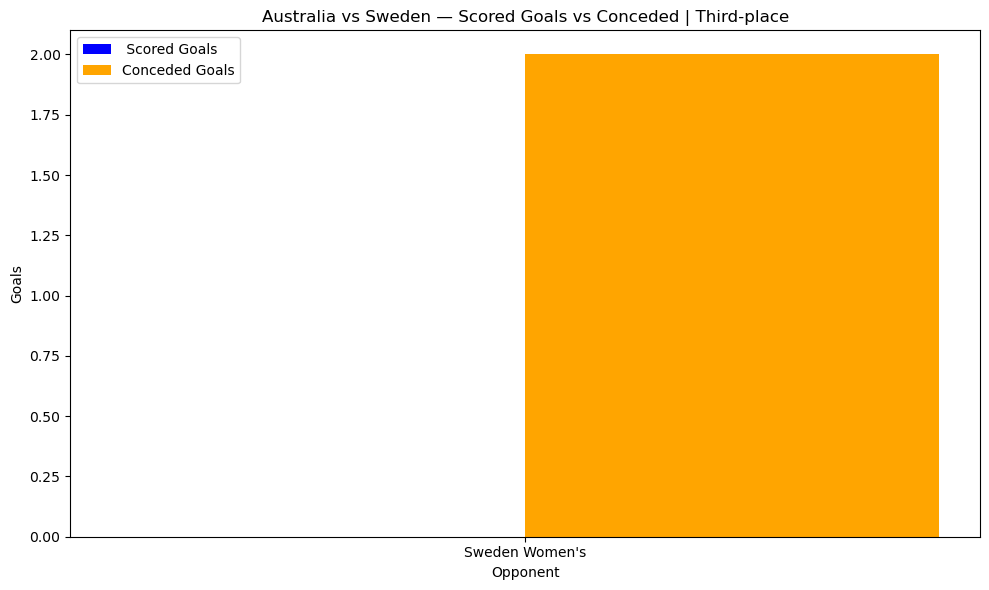

In [18]:
trdplace = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Australia Women's") &
    (womens_world_cup_stats["stage"] == "Third-place")
].copy()

trdplace["match_date"] = pd.to_datetime(trdplace["match_date"])

trdplace = trdplace.sort_values("match_date")

x = np.arange(len(trdplace))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    trdplace["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    trdplace["goals_against"],
    width,
    label= "Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    trdplace["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Australia vs Sweden — Scored Goals vs Conceded | Third-place")

plt.legend()

plt.tight_layout()
plt.show()

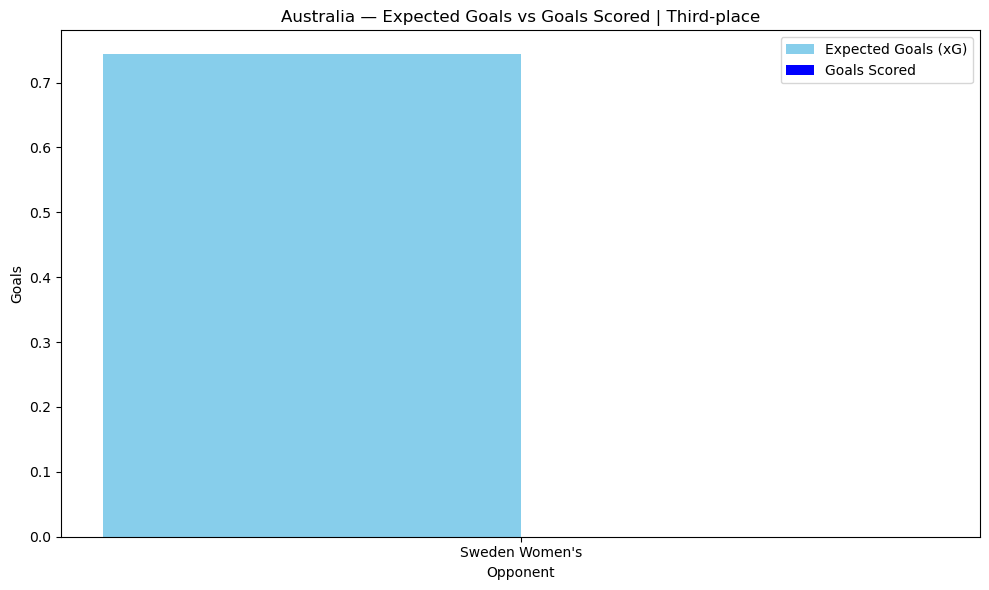

In [22]:
trdplace = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Australia Women's") &
    (womens_world_cup_stats["stage"] == "Third-place")
].copy()

trdplace["match_date"] = pd.to_datetime(trdplace["match_date"])

trdplace = trdplace.sort_values("match_date")

x = np.arange(len(trdplace))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    trdplace["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    trdplace["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    trdplace["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Australia — Expected Goals vs Goals Scored | Third-place")

plt.legend()

plt.tight_layout()
plt.show()

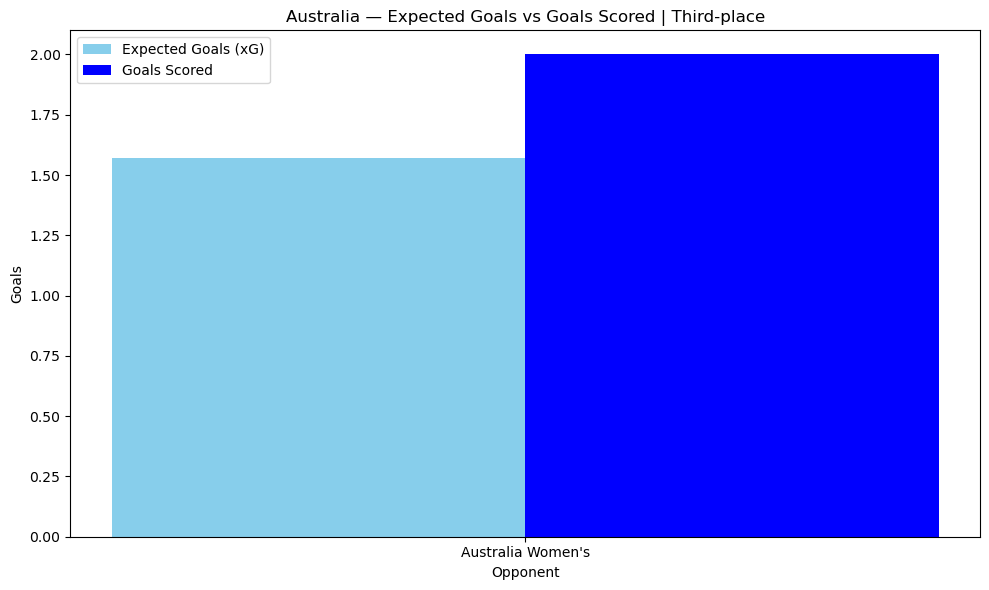

In [24]:
trdplace = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Sweden Women's") &
    (womens_world_cup_stats["stage"] == "Third-place")
].copy()

trdplace["match_date"] = pd.to_datetime(trdplace["match_date"])

trdplace = trdplace.sort_values("match_date")

x = np.arange(len(trdplace))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    trdplace["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    trdplace["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    trdplace["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Australia — Expected Goals vs Goals Scored | Third-place")

plt.legend()

plt.tight_layout()
plt.show()

In [28]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Australia Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "Australia Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries",
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Australia": [
        match.loc[
            match["team"] == "Australia Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Sweden": [
        match.loc[
            match["team"] == "Sweden Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "Sweden"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "Sweden"]
].round(1)


# Display table

comparison

,Metric,Australia,Sweden
0,Goals,0,2
1,xG,0.743337,1.57015
2,Goals Minus xG,-0.743337,0.42985
3,Shots,11,11
4,Shots on Target,4,5
5,Saves,3,4
6,Possession %,52.821967,47.178033
7,Pass Accuracy %,67.942584,74.321503
8,Progressive Passes,103.0,103.0
9,Progressive Carries,10.0,15.0


Teams found:
["Australia Women's" "Sweden Women's"]


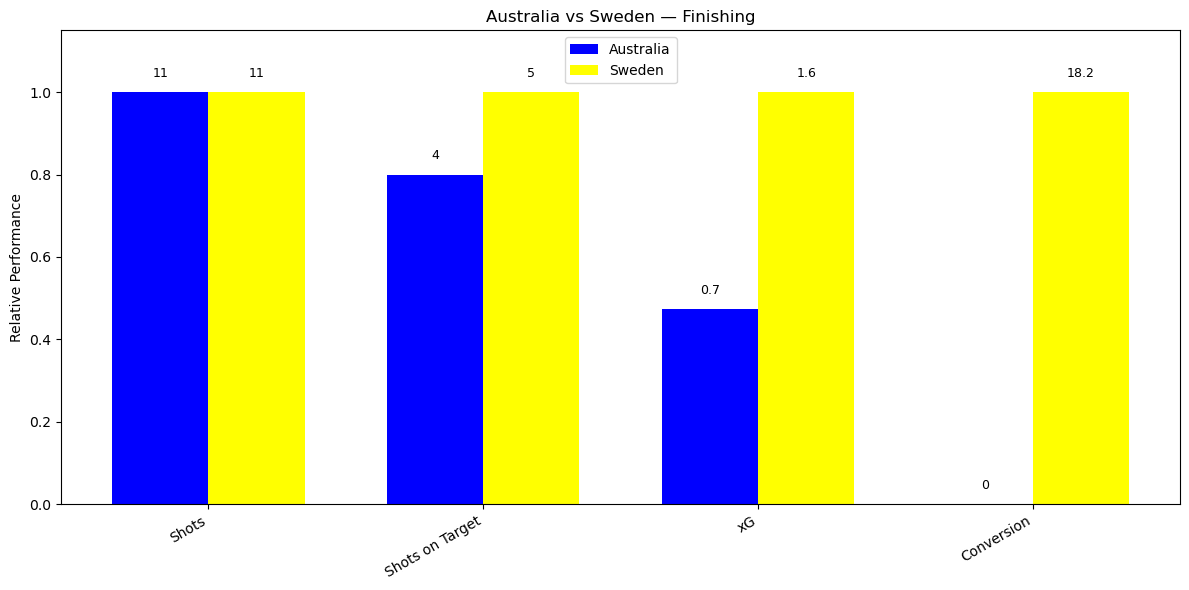

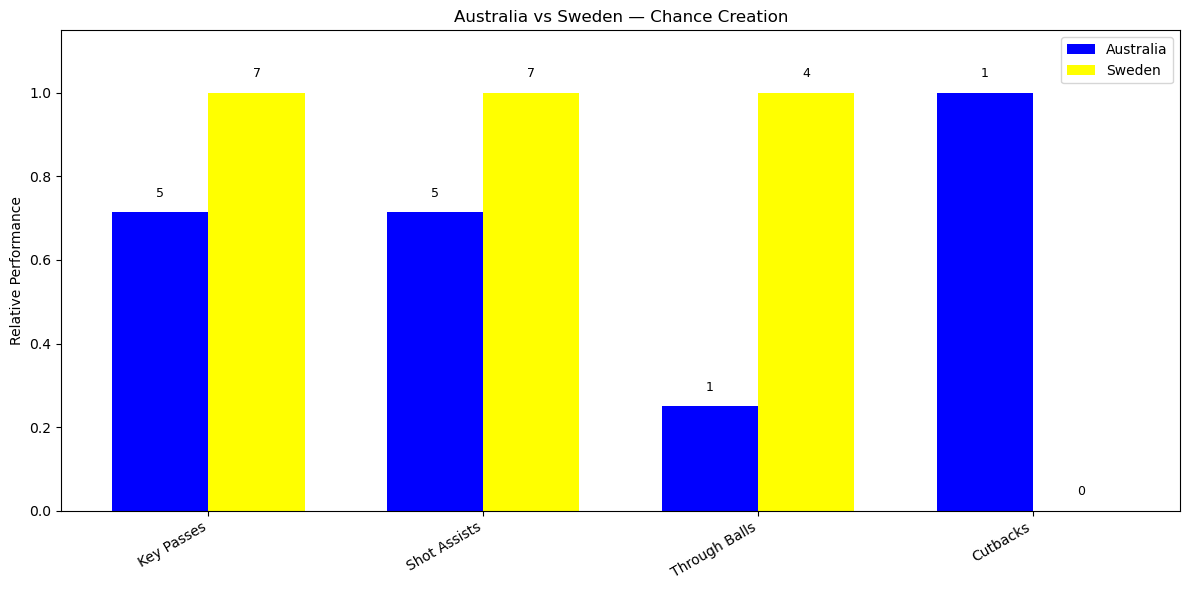

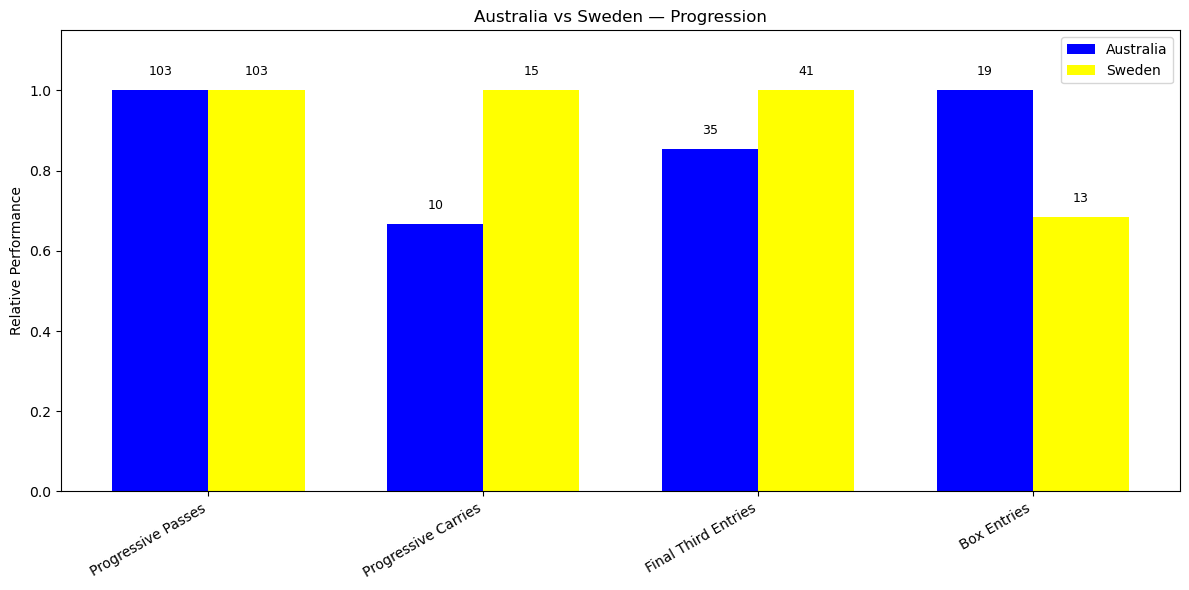

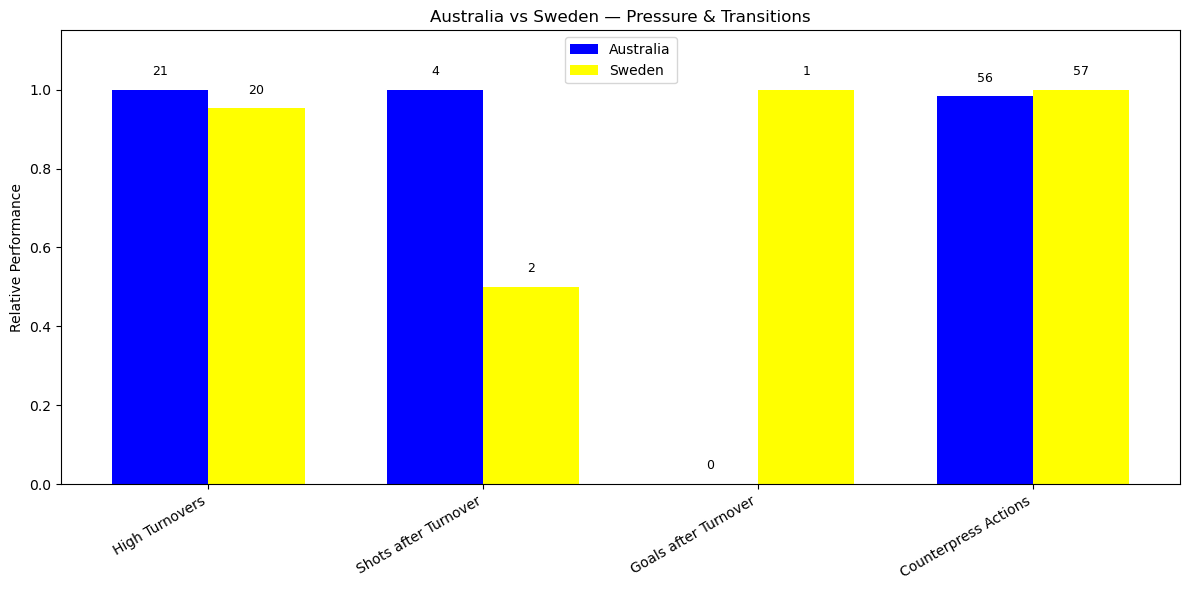

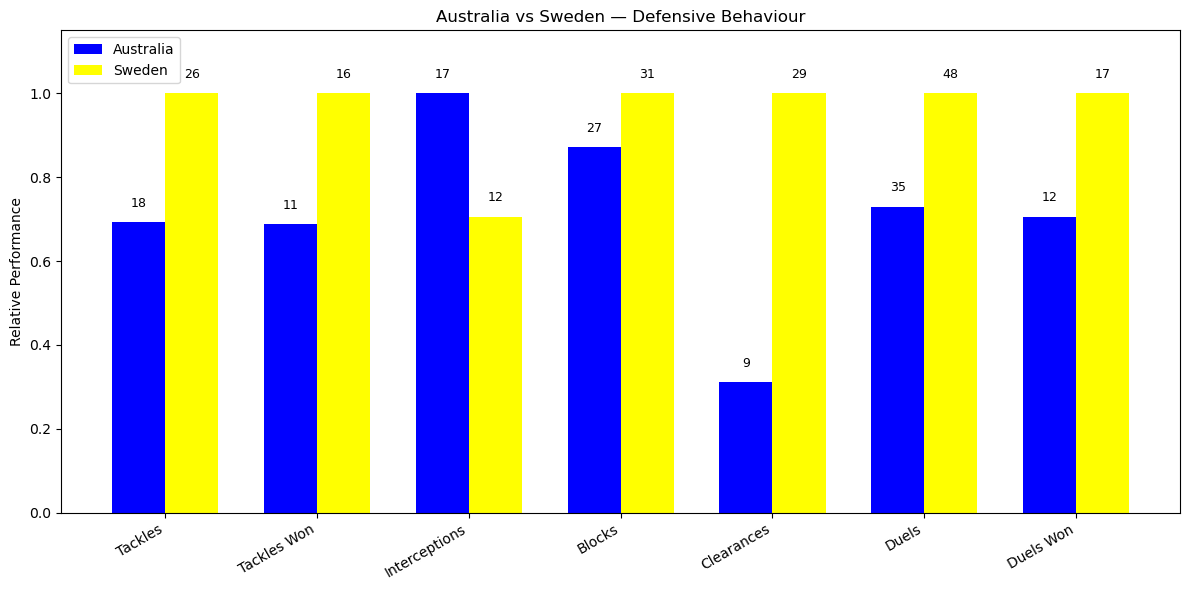

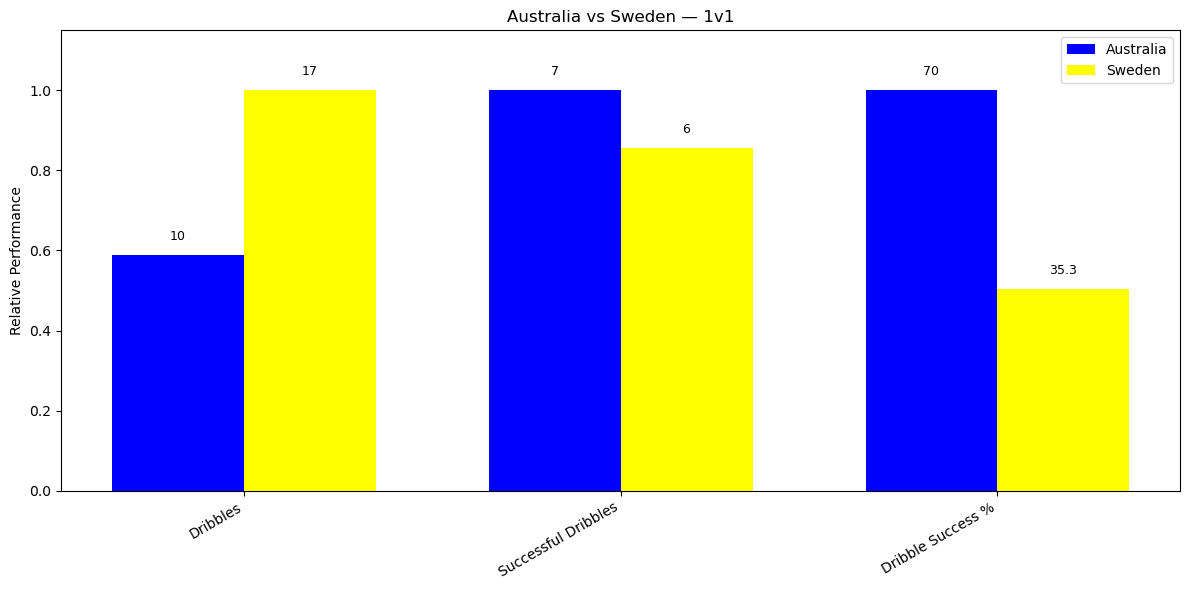

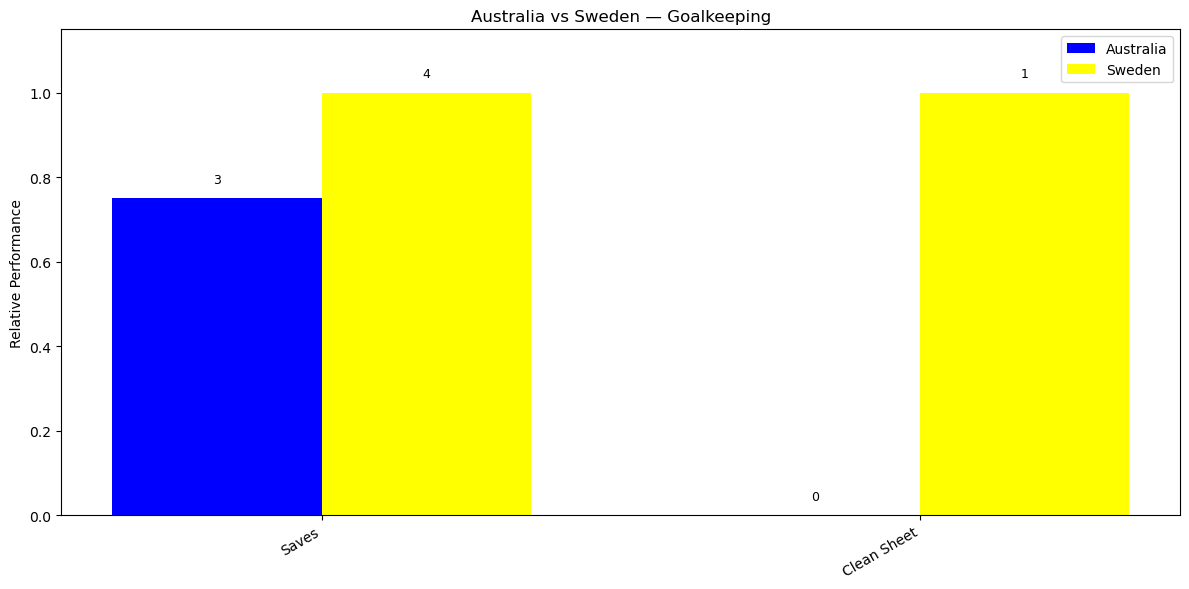

In [30]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (
            (womens_world_cup_stats["team"] == "Australia Women's") &
            (womens_world_cup_stats["opponent"] == "Sweden Women's")
        )
        |
        (
            (womens_world_cup_stats["team"] == "Sweden Women's") &
            (womens_world_cup_stats["opponent"] == "Australia Women's")
        )
    )
    &
    (womens_world_cup_stats["stage"] == "Third-place")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "Australia": "Australia Women's",
    "Sweden": "Sweden Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    aus_values = np.array([
        match.loc[
            match["team"] == team_names["Australia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    swe_values = np.array([
        match.loc[
            match["team"] == team_names["Sweden"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        aus_values,
        swe_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    aus_normalized = np.divide(
        aus_values,
        max_values,
        out=np.zeros_like(aus_values),
        where=max_values != 0
    )


    swe_normalized = np.divide(
        swe_values,
        max_values,
        out=np.zeros_like(swe_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_aus = plt.bar(
        x - width / 2,
        aus_normalized,
        width,
        label="Australia",
        color="blue"
    )


    bars_swe = plt.bar(
        x + width / 2,
        swe_normalized,
        width,
        label="Sweden",
        color="yellow"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_aus,
        aus_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_swe,
        swe_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Australia vs Sweden — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [32]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
124,Australia Women's,Sweden Women's,4-2-3-1
125,Sweden Women's,Australia Women's,4-2-3-1


In [34]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "Australia": [
        match.loc[
            match["team"] == "Australia Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "clearances"
        ].iloc[0]
    ],

    "Sweden": [
        match.loc[
            match["team"] == "Sweden Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Australia", "Sweden"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Australia", "Sweden"]
].round(1)

formation_comparison

,Metric,Australia,Sweden
0,Formation,4-2-3-1,4-2-3-1
1,Possession %,52.821967,47.178033
2,Shots,11,11
3,xG,0.743337,1.57015
4,Progressive Passes,103.0,103.0
5,Progressive Carries,10.0,15.0
6,Final Third Entries,35.0,41.0
7,Box Entries,19.0,13.0
8,High Turnovers,21.0,20.0
9,Interceptions,17,12


# Conclusion AUS-SWE

The game was fairly balanced, which was also reflected in the identical 4-2-3-1 formations. Both teams recorded similar values in progression, pressure and shot volume, with 11 shots each. However, Sweden created higher-quality chances, recording 1.57 xG compared with Australia's 0.74, while also having better shot accuracy and pass accuracy.

The main difference came from Sweden's greater attacking efficiency and defensive strength. Sweden converted two of their five shots on target, while Australia failed to score despite four shots on target. Defensively, Sweden also recorded more tackles won, blocks and clearances, making their defensive performance considerably stronger and ultimately contributing to the victory.